# Аналитическая часть

In [2]:
#импортирование библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

### Загрузка и характеристика датасетов:

In [3]:
print('Первый датасет:X_bp.xlsx')
df_bp = pd.read_excel('X_bp.xlsx', index_col=0) #Столбец Unnamed: 0 исключён как технический дубликат индекса
print(f"Размер: {df_bp.shape[0]} строки, {df_bp.shape[1]} столбцов")

Первый датасет:X_bp.xlsx
Размер: 1023 строки, 10 столбцов


In [4]:
#просмотр первых пяти строк первого датасета
df_bp.head()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2"
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0


In [5]:
print('Второй датасет:X_nup.xlsx')
df_nup = pd.read_excel('X_nup.xlsx', index_col=0) #Столбец Unnamed: 0 исключён как технический дубликат индекса
print(f"Размер: {df_nup.shape[0]} строк, {df_nup.shape[1]} столбца")

Второй датасет:X_nup.xlsx
Размер: 1040 строк, 3 столбца


In [6]:
#просмотр первых пяти строк второго датасета 
df_nup.head()

,"Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,0,4.0,57.0
1,0,4.0,60.0
2,0,4.0,70.0
3,0,5.0,47.0
4,0,5.0,57.0


### Объединение датасетов:

In [7]:
df = pd.merge(df_bp, df_nup, left_index=True, right_index=True, how='inner')
print(f"Размер объединённого датасета: {df.shape[0]} строки, {df.shape[1]} столбцов")

Размер объединённого датасета: 1023 строки, 13 столбцов


In [8]:
#просмотр первых пяти строк объединённого датасета 
df.head().T #атрибут T использован для удобного просмотра всех столбцов

,0,1,2,3,4
Соотношение матрица-наполнитель,1.857143,1.857143,1.857143,1.857143,2.771331
"Плотность, кг/м3",2030.000000,2030.000000,2030.000000,2030.000000,2030.000000
"модуль упругости, ГПа",738.736842,738.736842,738.736842,738.736842,753.000000
"Количество отвердителя, м.%",30.000000,50.000000,49.900000,129.000000,111.860000
"Содержание эпоксидных групп,%_2",22.267857,23.750000,33.000000,21.250000,22.267857
"Температура вспышки, С_2",100.000000,284.615385,284.615385,300.000000,284.615385
"Поверхностная плотность, г/м2",210.000000,210.000000,210.000000,210.000000,210.000000
"Модуль упругости при растяжении, ГПа",70.000000,70.000000,70.000000,70.000000,70.000000
"Прочность при растяжении, МПа",3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
"Потребление смолы, г/м2",220.000000,220.000000,220.000000,220.000000,220.000000


In [9]:
df.info() #анализ информации о датафрейме

<class 'pandas.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки                 

In [10]:
print(df.isnull().sum()) #проверка на пропуски

Соотношение матрица-наполнитель         0
Плотность, кг/м3                        0
модуль упругости, ГПа                   0
Количество отвердителя, м.%             0
Содержание эпоксидных групп,%_2         0
Температура вспышки, С_2                0
Поверхностная плотность, г/м2           0
Модуль упругости при растяжении, ГПа    0
Прочность при растяжении, МПа           0
Потребление смолы, г/м2                 0
Угол нашивки, град                      0
Шаг нашивки                             0
Плотность нашивки                       0
dtype: int64


In [11]:
print(df.duplicated().sum()) #проверка на дубликаты

0


In [12]:
print(df.nunique()) #проверка количества уникальных значений в каждом столбце

Соотношение матрица-наполнитель         1014
Плотность, кг/м3                        1013
модуль упругости, ГПа                   1020
Количество отвердителя, м.%             1005
Содержание эпоксидных групп,%_2         1004
Температура вспышки, С_2                1003
Поверхностная плотность, г/м2           1004
Модуль упругости при растяжении, ГПа    1004
Прочность при растяжении, МПа           1004
Потребление смолы, г/м2                 1003
Угол нашивки, град                         2
Шаг нашивки                              989
Плотность нашивки                        988
dtype: int64


In [13]:
#в столбце "Угол нашивки" только два уникальных значений
df['Угол нашивки, град'].value_counts() 

Угол нашивки, град
0     520
90    503
Name: count, dtype: int64

In [14]:
df['Угол нашивки, град'] = df['Угол нашивки, град'].replace({90: 1, 0: 0}) #приведение бинарного признака к виду {0, 1} для единообразия

In [15]:
df['Угол нашивки, град'] #просмотр успешного изменения значений

0       0
1       0
2       0
3       0
4       0
       ..
1018    1
1019    1
1020    1
1021    1
1022    1
Name: Угол нашивки, град, Length: 1023, dtype: int64

### Разведочный анализ данных

In [16]:
df.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,0.491691,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,0.500175,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,1.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,1.000000,14.440522,103.988901


### Визуализация

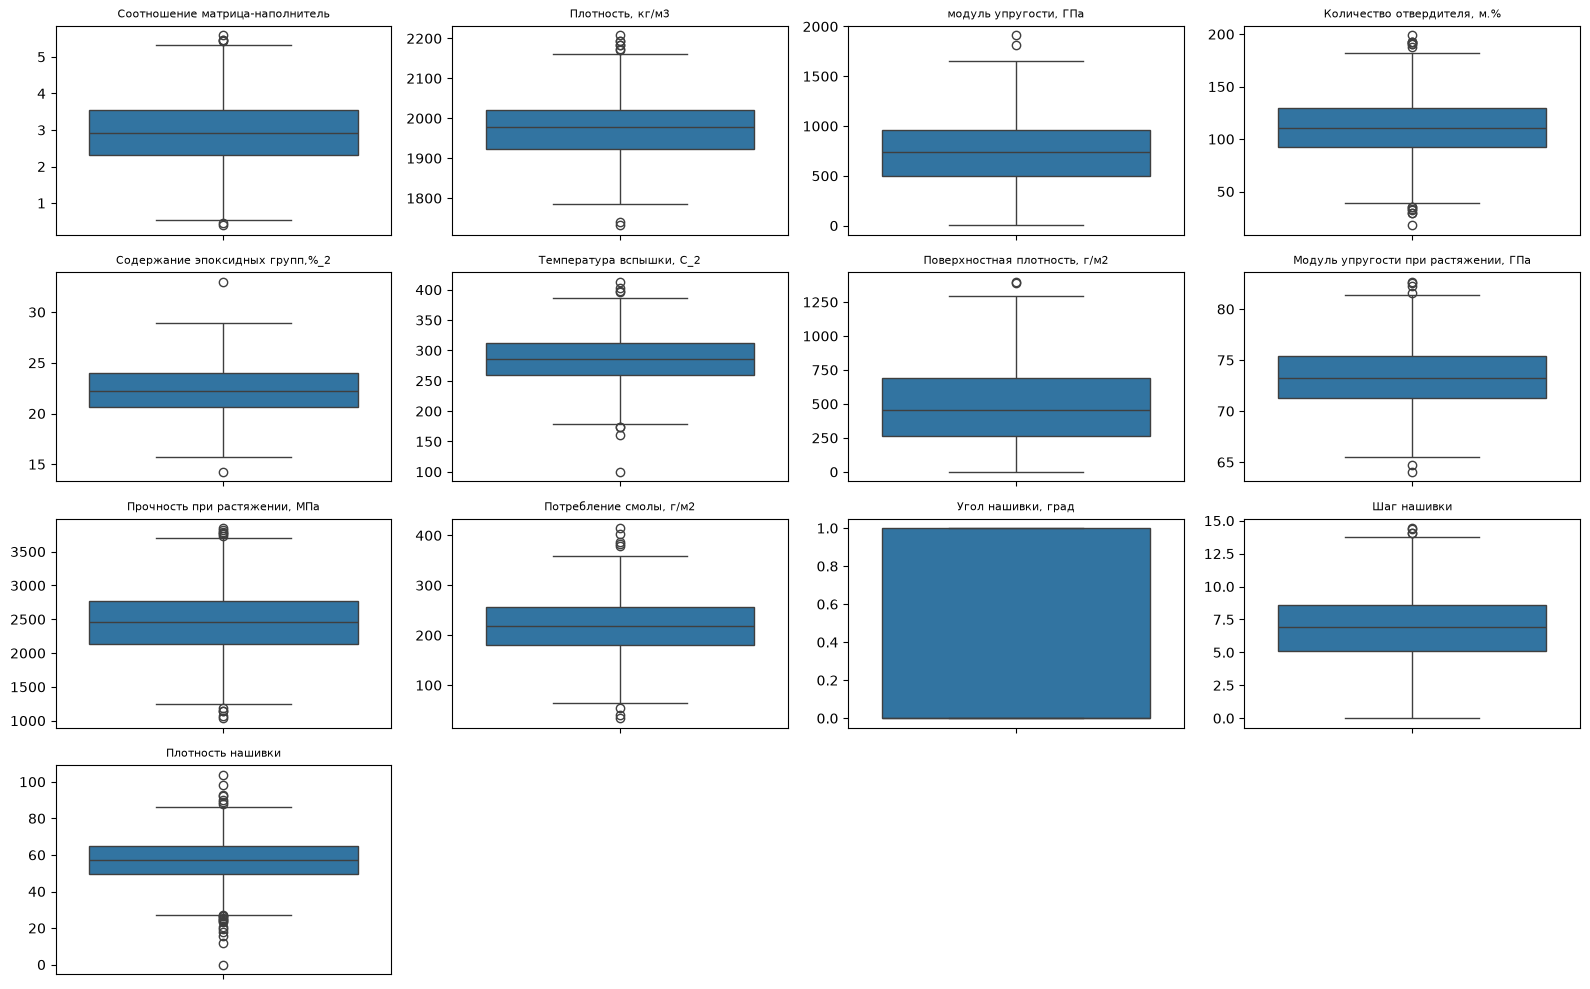

In [17]:
#"Ящик с усами" (боксплот) для каждого столбца
plt.figure(figsize=(16, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=8)
    plt.ylabel('')
plt.tight_layout()
plt.show()

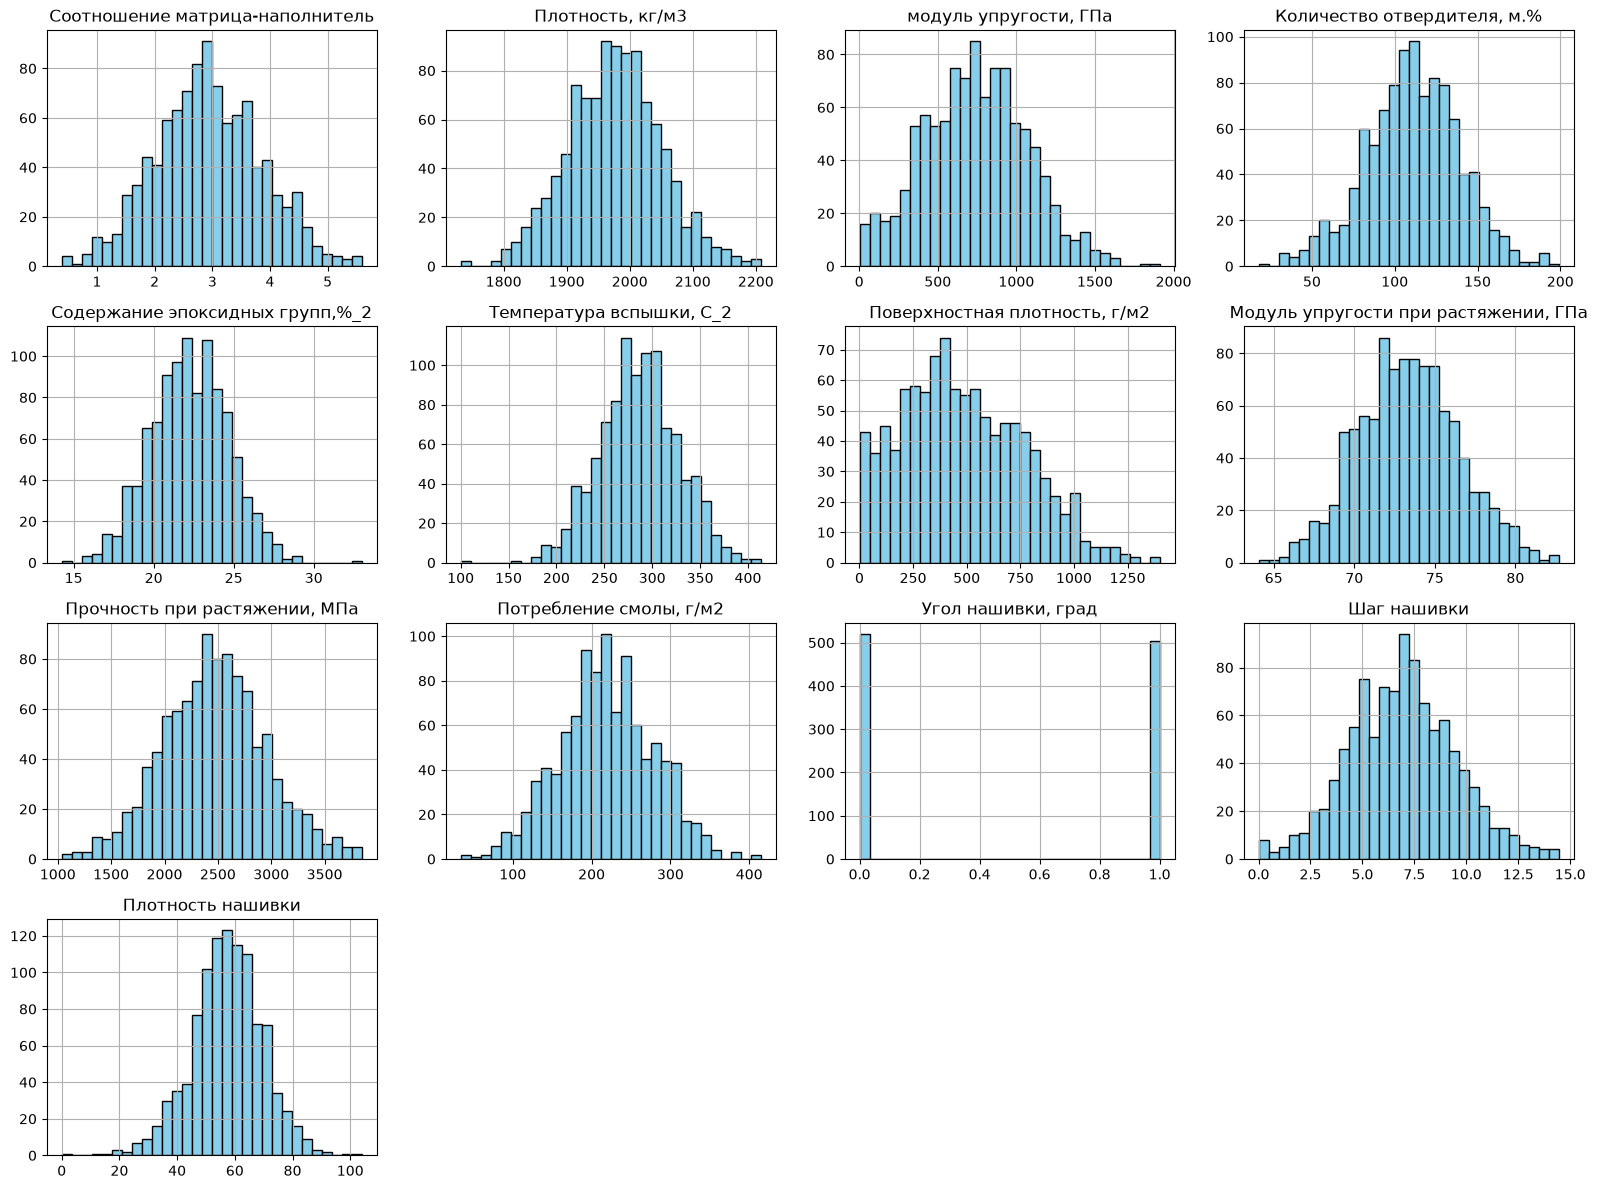

In [18]:
#гистограммы
df.hist(figsize=(16, 12), bins=30, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

In [19]:
#критерий Шапиро-Уилка
from scipy.stats import shapiro

normal_cols = []
non_normal_cols = []

for col in df.columns:
    stat, p = shapiro(df[col])
    if p > 0.05:
        normal_cols.append(col)
    else:
        non_normal_cols.append(col)

print("С нормальным распределением (p > 0.05):")
print(normal_cols)
print("\nБез нормального распределения (p <= 0.05):")
print(non_normal_cols)

С нормальным распределением (p > 0.05):
['Соотношение матрица-наполнитель', 'Плотность, кг/м3', 'Количество отвердителя, м.%', 'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа', 'Потребление смолы, г/м2', 'Шаг нашивки']

Без нормального распределения (p <= 0.05):
['модуль упругости, ГПа', 'Поверхностная плотность, г/м2', 'Угол нашивки, град', 'Плотность нашивки']


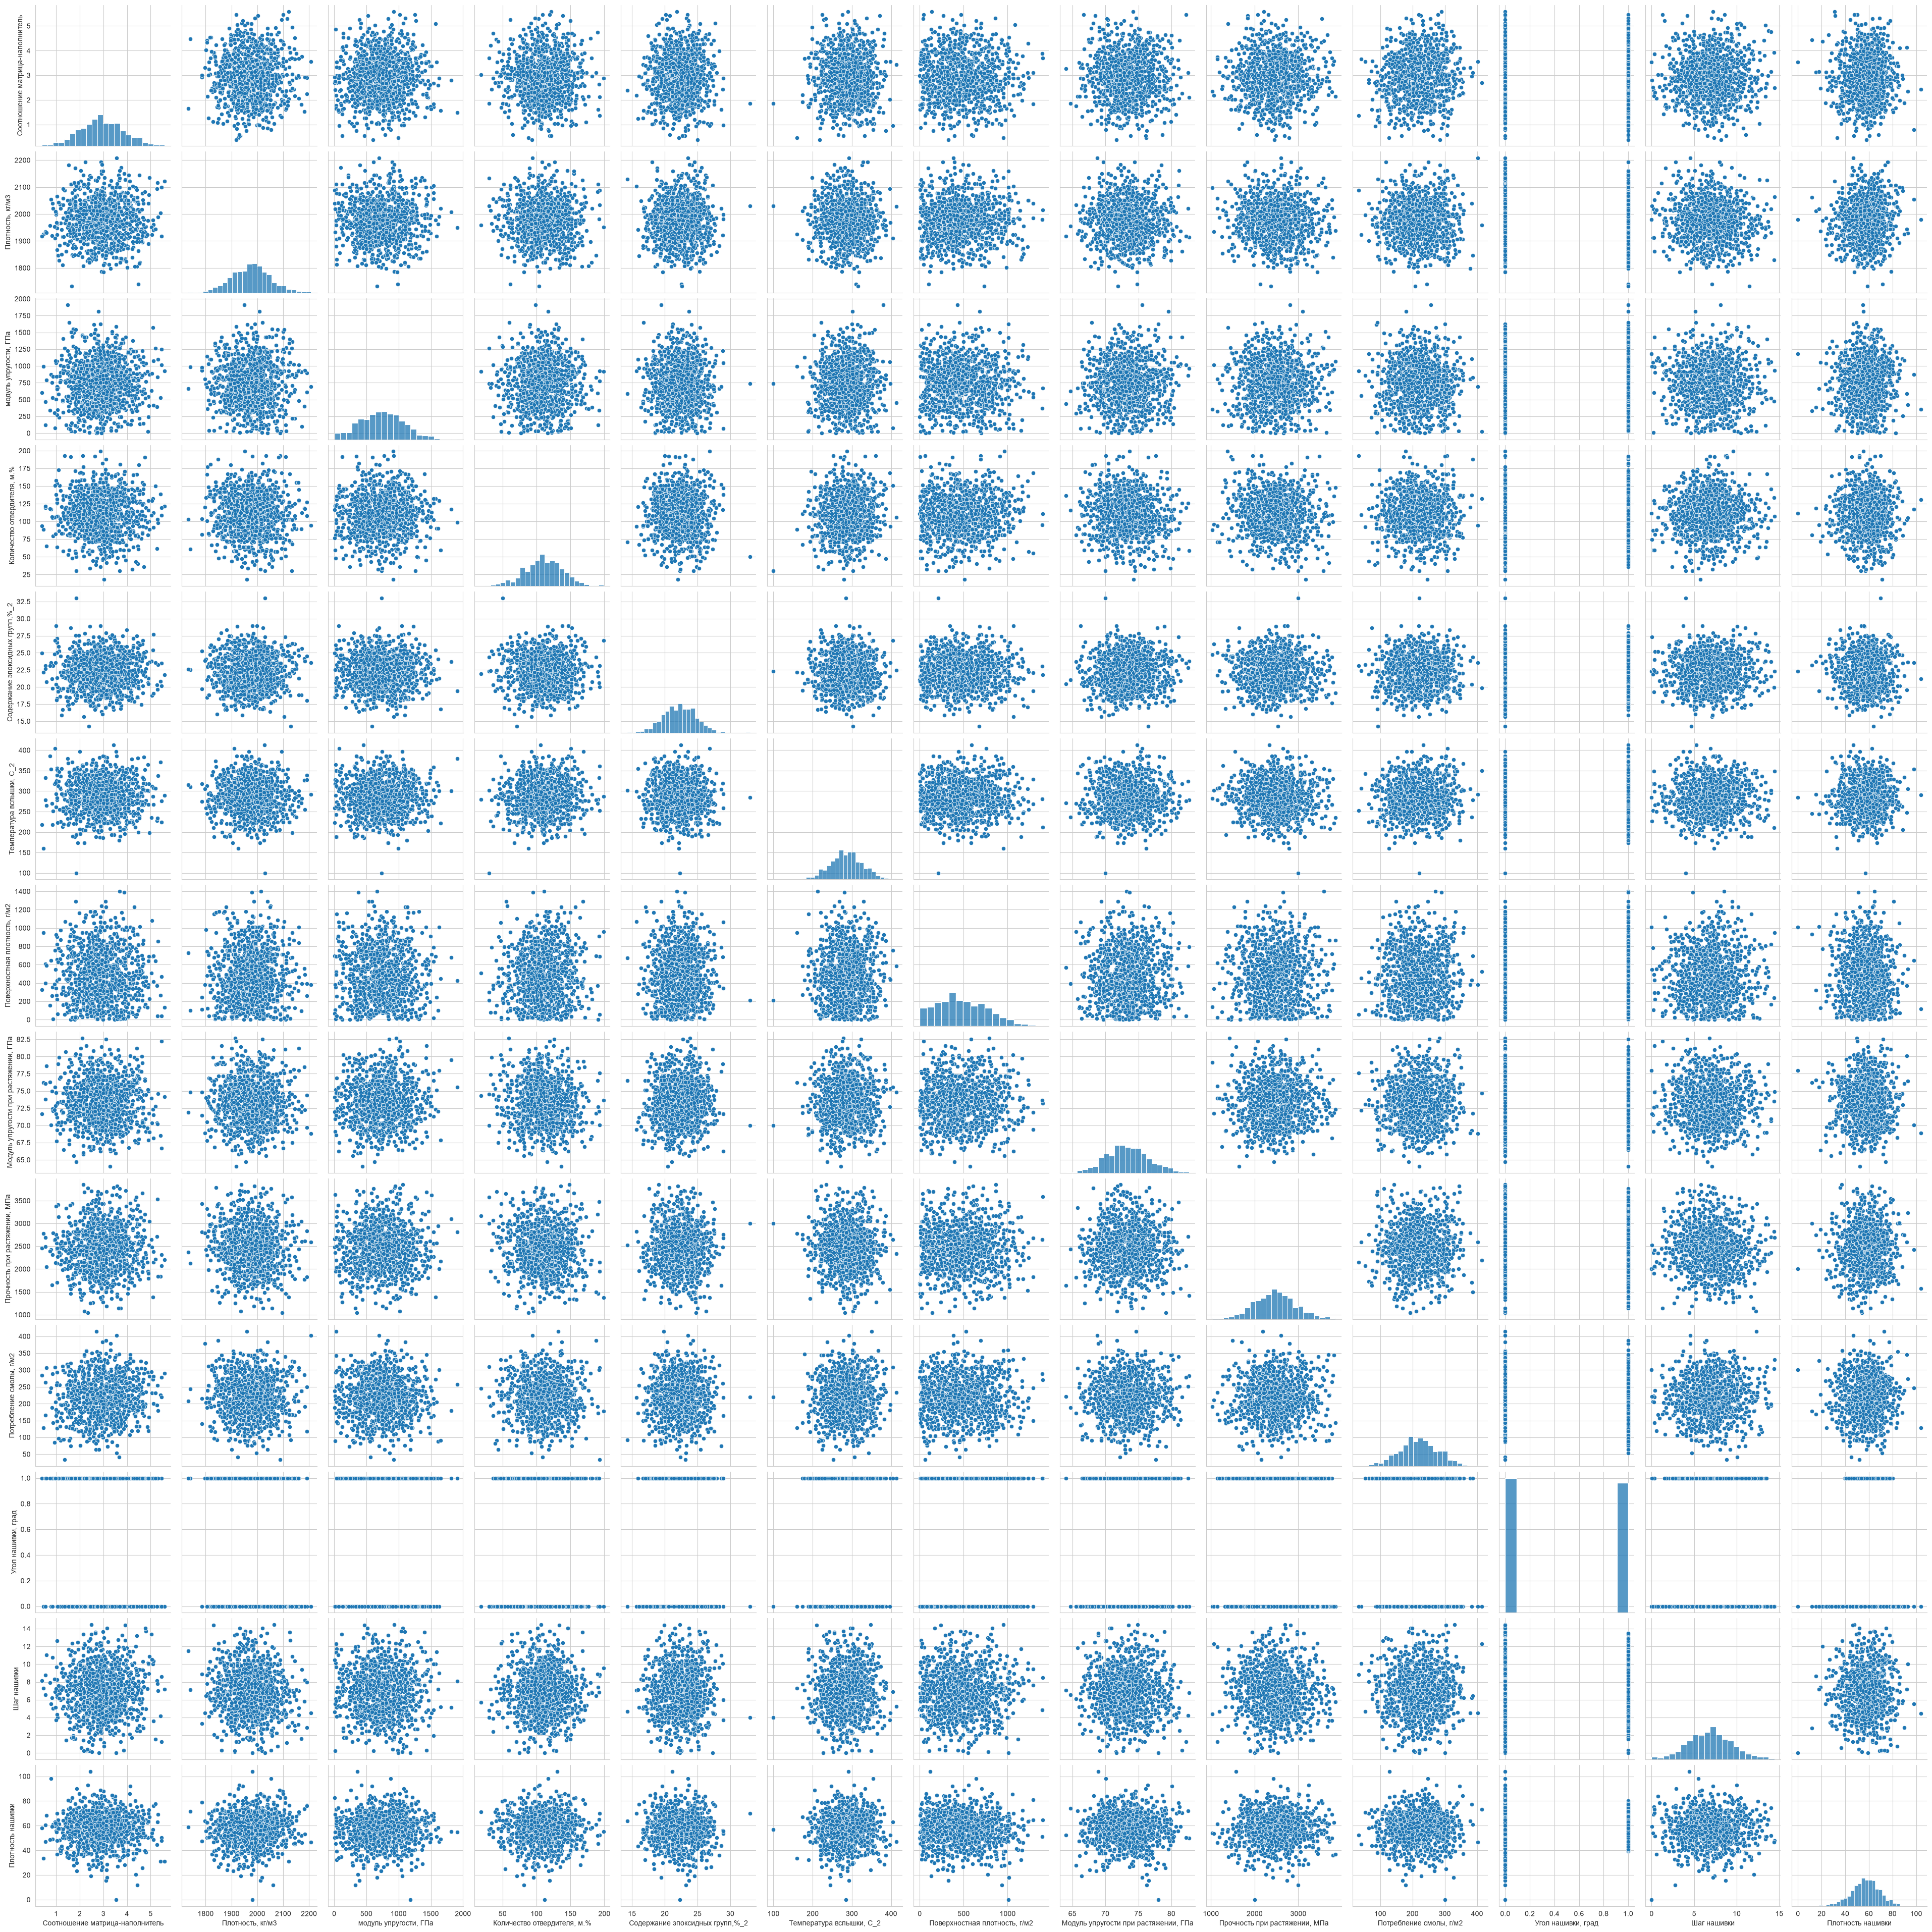

In [20]:
#попарные графики рассеяния 
sns.set_style('whitegrid')
sns.pairplot(df, height=3)
plt.show()

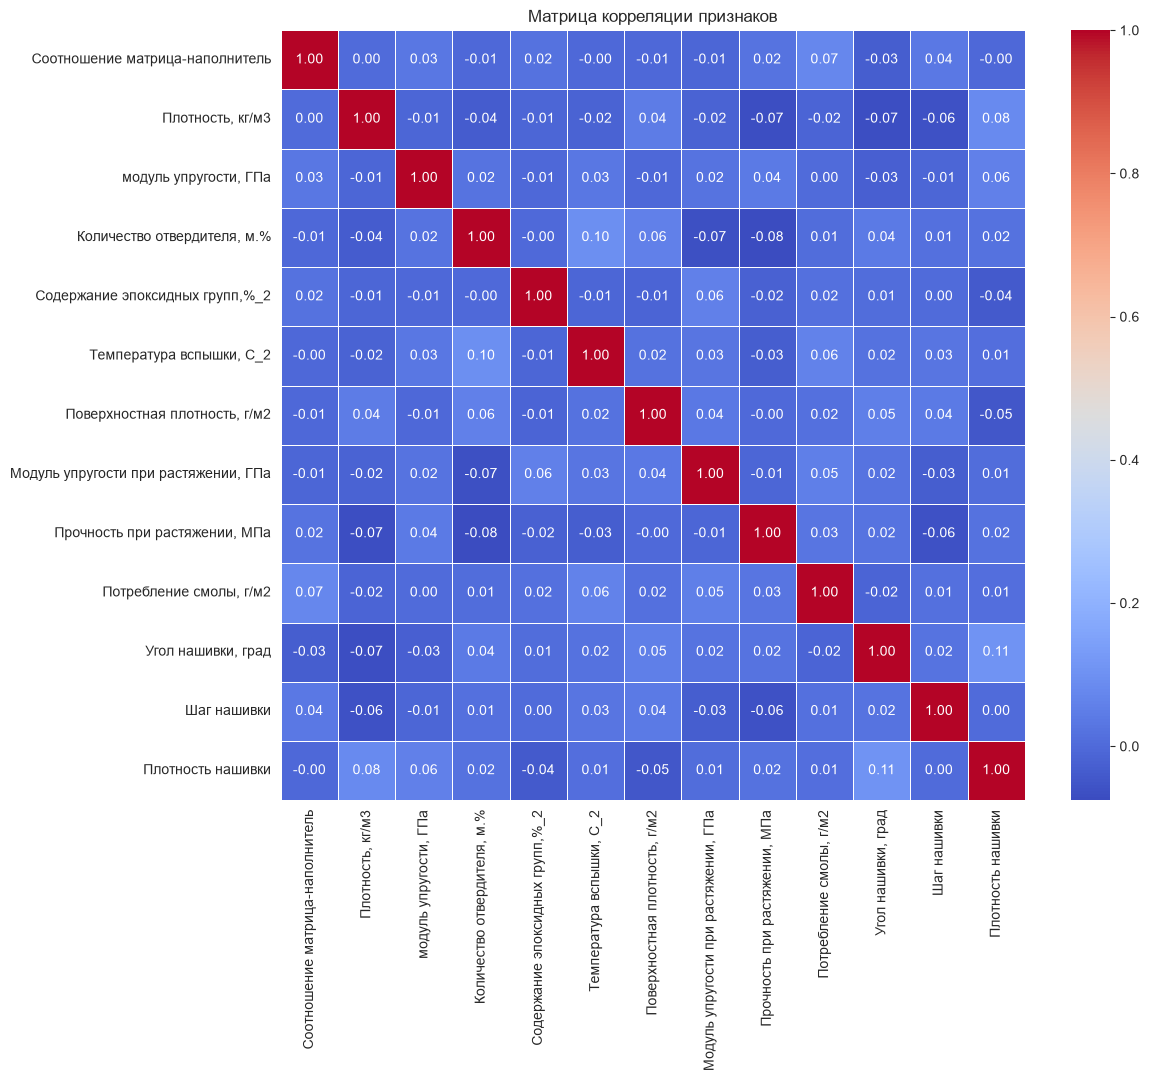

In [21]:
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.show()

# Практическая часть

In [22]:
# Удаление выбросов по IQR-методу 
df_clean = df.copy()

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    min_val = Q1 - 1.5 * IQR
    max_val = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= min_val) & (df_clean[col] <= max_val)]

print(f"Размер до удаления: {df.shape[0]}")
print(f"Размер после удаления: {df_clean.shape[0]}")
print(f"Удалено строк: {df.shape[0] - df_clean.shape[0]}")

Размер до удаления: 1023
Размер после удаления: 932
Удалено строк: 91


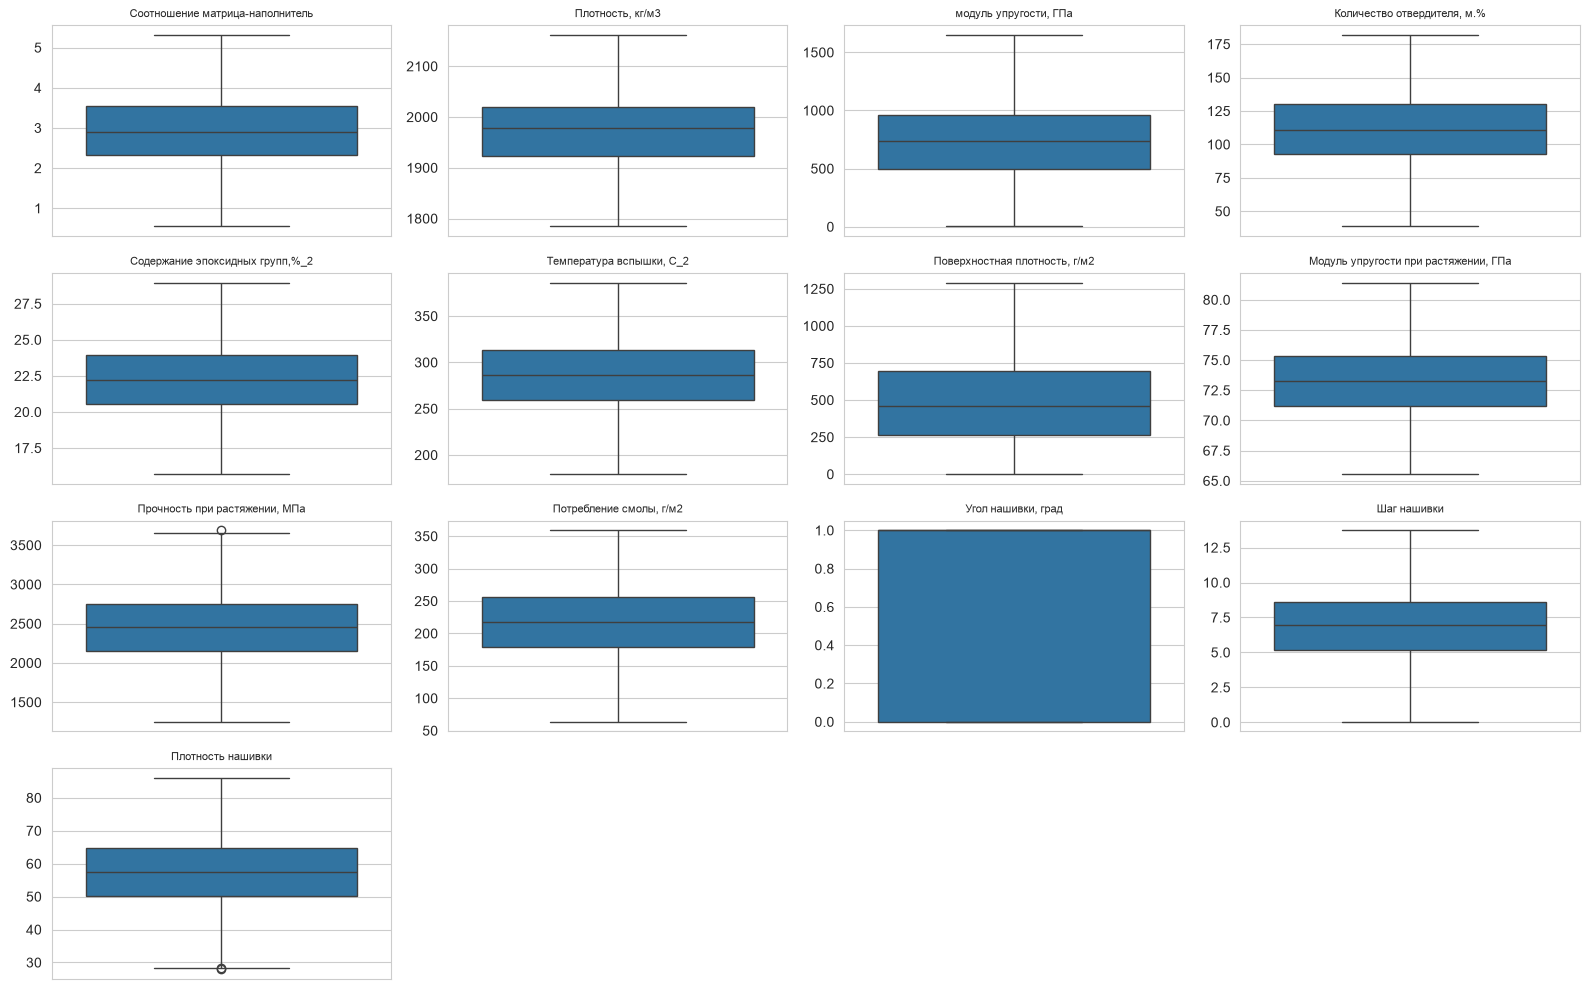

In [23]:
#проверка выбросов, они остались
plt.figure(figsize=(16, 10))
for i, col in enumerate(df_clean.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col, fontsize=8)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [24]:
#повторное использование метода IQR
df_clean = df.copy()

for _ in range(5):
    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        min_val = Q1 - 1.5 * IQR
        max_val = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= min_val) & (df_clean[col] <= max_val)]

print(f"Размер после удаления: {df_clean.shape[0]}")

Размер после удаления: 921


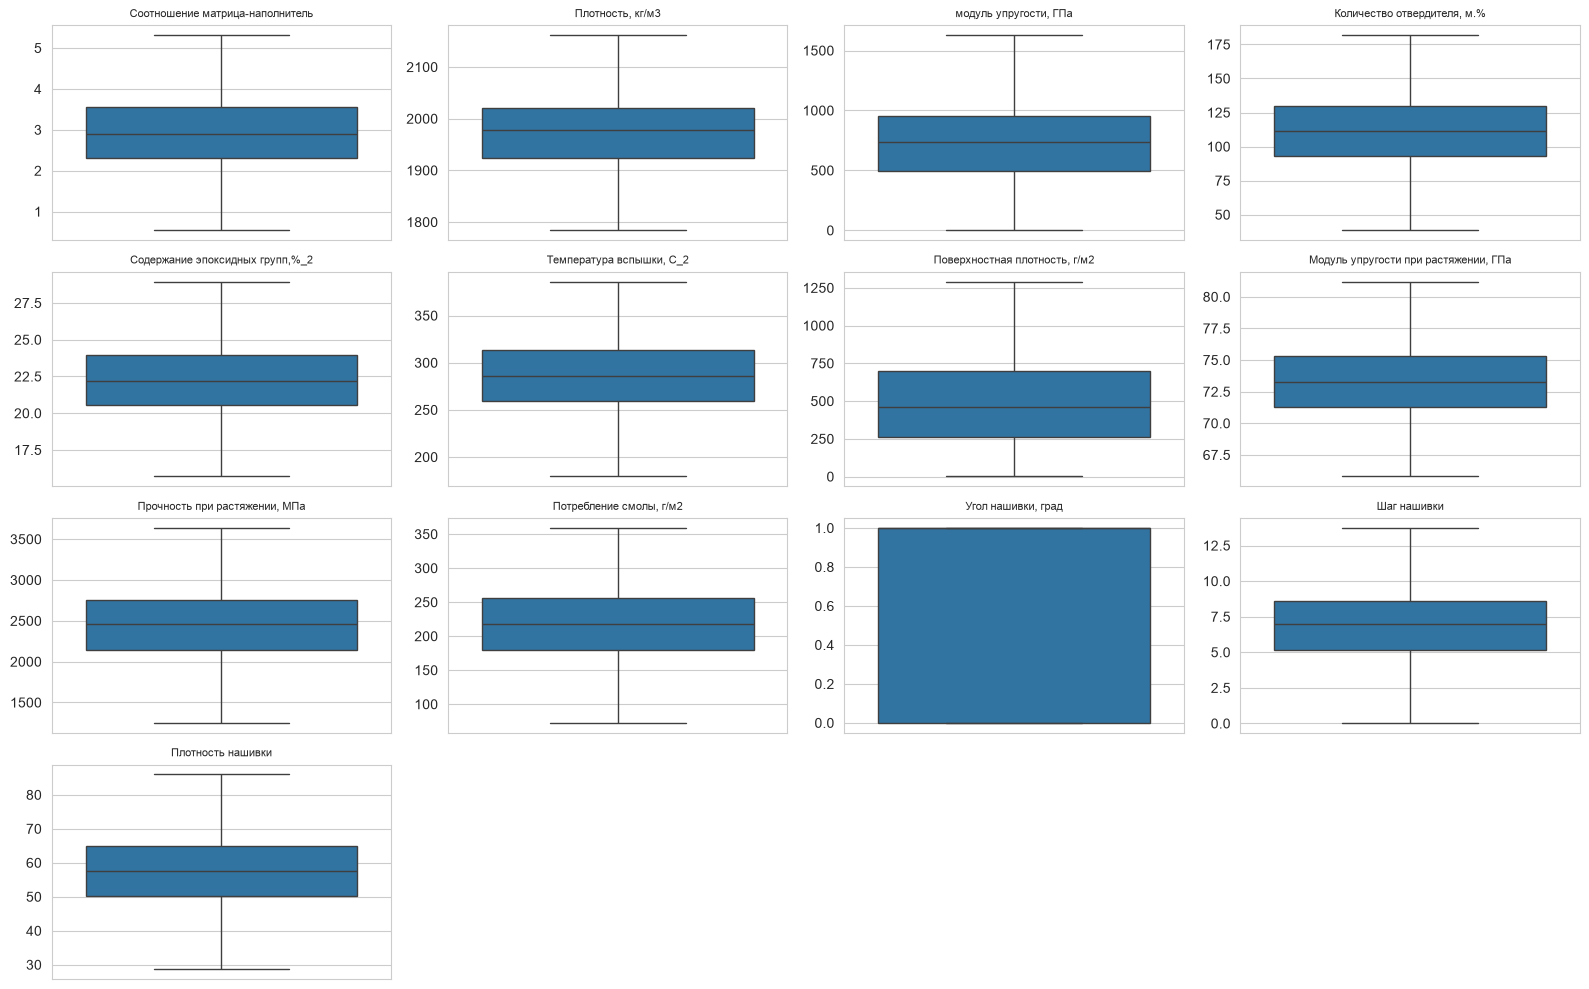

In [25]:
#проверка выбросов, они отсутствуют
plt.figure(figsize=(16, 10))
for i, col in enumerate(df_clean.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col, fontsize=8)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [26]:
#выбираем признаки для нормализации (все, кроме бинарного и выходных)
cols_to_scale = [col for col in df_clean.columns if col not in ['Угол нашивки, град', 'Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']]

scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("Масштабирование выполнено")
print(df_scaled[cols_to_scale].describe())

Масштабирование выполнено
       Соотношение матрица-наполнитель  Плотность, кг/м3  \
count                       921.000000        921.000000   
mean                          0.499417          0.502792   
std                           0.187960          0.188467   
min                           0.000000          0.000000   
25%                           0.371727          0.368017   
50%                           0.495389          0.511348   
75%                           0.629915          0.624865   
max                           1.000000          1.000000   

       модуль упругости, ГПа  Количество отвердителя, м.%  \
count             921.000000                   921.000000   
mean                0.451172                     0.506224   
std                 0.201579                     0.186977   
min                 0.000000                     0.000000   
25%                 0.305176                     0.378362   
50%                 0.450507                     0.506411   
75%   

In [27]:
#датасет до нормализации
print("до нормализации (MinMaxScaler):")
df_clean[cols_to_scale].head()

до нормализации (MinMaxScaler):


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Потребление смолы, г/м2",Шаг нашивки,Плотность нашивки
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,220.0,4.0,60.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,220.0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,220.0,5.0,57.0
5,2.767918,2000.0,748.000000,111.86,22.267857,284.615385,210.0,220.0,5.0,60.0
6,2.569620,1910.0,807.000000,111.86,22.267857,284.615385,210.0,220.0,5.0,70.0


In [28]:
#датасет после нормализации
print("после нормализации (MinMaxScaler):")
df_scaled[cols_to_scale].head()

после нормализации (MinMaxScaler):


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Потребление смолы, г/м2",Шаг нашивки,Плотность нашивки
1,0.274768,0.651097,0.452951,0.079153,0.607435,0.509164,0.16223,0.514688,0.289334,0.546433
3,0.274768,0.651097,0.452951,0.630983,0.418887,0.583596,0.16223,0.514688,0.362355,0.319758
4,0.466552,0.651097,0.461725,0.511257,0.495653,0.509164,0.16223,0.514688,0.362355,0.494123
5,0.465836,0.571539,0.458649,0.511257,0.495653,0.509164,0.16223,0.514688,0.362355,0.546433
6,0.424236,0.332865,0.494944,0.511257,0.495653,0.509164,0.16223,0.514688,0.362355,0.720799


In [29]:
#проверяем min и max для признаков до нормализации
print("Минимальные значения ДО нормализации:")
print(df_clean[cols_to_scale].min())
print("\nМаксимальные значения ДО нормализации:")
print(df_clean[cols_to_scale].max())

Минимальные значения ДО нормализации:
Соотношение матрица-наполнитель       0.547391
Плотность, кг/м3                   1784.482245
модуль упругости, ГПа                 2.436909
Количество отвердителя, м.%          38.668500
Содержание эпоксидных групп,%_2      15.695894
Температура вспышки, С_2            179.374391
Поверхностная плотность, г/м2         0.603740
Потребление смолы, г/м2              72.530873
Шаг нашивки                           0.037639
Плотность нашивки                    28.661632
dtype: float64

Максимальные значения ДО нормализации:
Соотношение матрица-наполнитель       5.314144
Плотность, кг/м3                   2161.565216
модуль упругости, ГПа              1628.000000
Количество отвердителя, м.%         181.828448
Содержание эпоксидных групп,%_2      28.955094
Температура вспышки, С_2            386.067992
Поверхностная плотность, г/м2      1291.340115
Потребление смолы, г/м2             359.052220
Шаг нашивки                          13.732404
Плотность наши

In [30]:
#проверяем min и max для всех нормализованных признаков
print("Минимальные значения после нормализации:")
print(df_scaled[cols_to_scale].min())
print("\nМаксимальные значения после нормализации:")
print(df_scaled[cols_to_scale].max())

Минимальные значения после нормализации:
Соотношение матрица-наполнитель    0.0
Плотность, кг/м3                   0.0
модуль упругости, ГПа              0.0
Количество отвердителя, м.%        0.0
Содержание эпоксидных групп,%_2    0.0
Температура вспышки, С_2           0.0
Поверхностная плотность, г/м2      0.0
Потребление смолы, г/м2            0.0
Шаг нашивки                        0.0
Плотность нашивки                  0.0
dtype: float64

Максимальные значения после нормализации:
Соотношение матрица-наполнитель    1.0
Плотность, кг/м3                   1.0
модуль упругости, ГПа              1.0
Количество отвердителя, м.%        1.0
Содержание эпоксидных групп,%_2    1.0
Температура вспышки, С_2           1.0
Поверхностная плотность, г/м2      1.0
Потребление смолы, г/м2            1.0
Шаг нашивки                        1.0
Плотность нашивки                  1.0
dtype: float64


In [31]:
#сохраним очищенный, нормализованный датасет
df_scaled.to_csv('df_scaled.csv', index=False)

In [33]:
#Сохранение scaler для приложения
import joblib
from sklearn.preprocessing import MinMaxScaler

# Создаём scaler ТОЛЬКО для 9 входных признаков нейросети
# (исключаем: бинарный, 2 целевые, и само Соотношение матрица-наполнитель)
cols_for_nn = [col for col in df_clean.columns 
               if col not in ['Угол нашивки, град', 
                              'Модуль упругости при растяжении, ГПа', 
                              'Прочность при растяжении, МПа',
                              'Соотношение матрица-наполнитель']]

print(f"Нормализуем {len(cols_for_nn)} признаков:")
for i, col in enumerate(cols_for_nn, 1):
    print(f"  {i}. {col}")

scaler_nn = MinMaxScaler()
scaler_nn.fit(df_clean[cols_for_nn])
joblib.dump(scaler_nn, 'scaler_minmax.pkl')

print(f"\n Scaler сохранён: scaler_minmax.pkl")
print(f"Пример: min={scaler_nn.data_min_[0]:.2f}, max={scaler_nn.data_max_[0]:.2f}")

Нормализуем 9 признаков:
  1. Плотность, кг/м3
  2. модуль упругости, ГПа
  3. Количество отвердителя, м.%
  4. Содержание эпоксидных групп,%_2
  5. Температура вспышки, С_2
  6. Поверхностная плотность, г/м2
  7. Потребление смолы, г/м2
  8. Шаг нашивки
  9. Плотность нашивки

 Scaler сохранён: scaler_minmax.pkl
Пример: min=1784.48, max=2161.57
